In [ ]:
# Load necessary libraries
library(dplyr)
library(ggplot2)
library(lubridate)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [ ]:
data <- read.csv("/content/HR_Analytics.csv")
head(data)

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,⋯,3,80,0,0,2,3,0,0,0,0
2,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,⋯,1,80,0,0,2,3,0,0,0,0
3,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,⋯,4,80,0,0,3,3,0,0,0,0
4,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,⋯,4,80,0,0,2,3,0,0,0,0
5,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,⋯,4,80,0,0,0,3,0,0,0,0
6,RM973,18,18-25,No,Non-Travel,1124,Research & Development,1,3,Life Sciences,⋯,3,80,0,0,5,4,0,0,0,0


In [ ]:
sum(is.na(data))

if (sum(is.na(data)) > 0) {
  data <- na.omit(data)
}

[1] 57

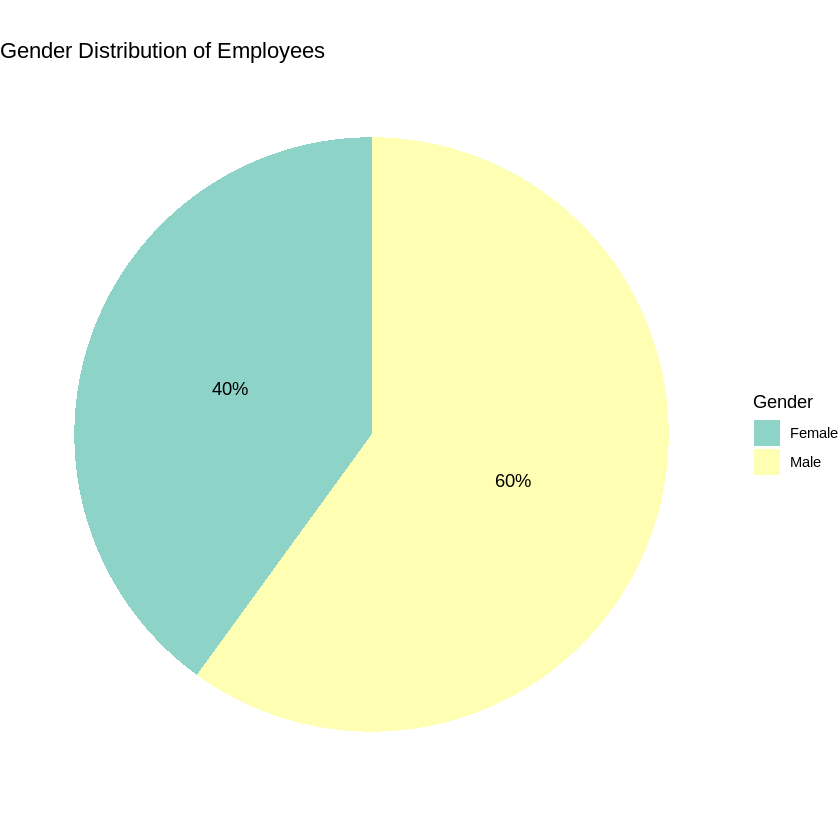

In [ ]:
# Gender distribution pie chart
gender_distribution <- data %>%
  group_by(Gender) %>%
  summarise(Count = n()) %>%
  mutate(Percentage = round(Count / sum(Count) * 100, 1))

# Plot
ggplot(gender_distribution, aes(x = "", y = Percentage, fill = Gender)) +
  geom_bar(width = 1, stat = "identity") +
  coord_polar("y", start = 0) +
  theme_void() +
  geom_text(aes(label = paste0(Percentage, "%")),
            position = position_stack(vjust = 0.5)) +
  labs(title = "Gender Distribution of Employees") +
  scale_fill_brewer(palette = "Set3")


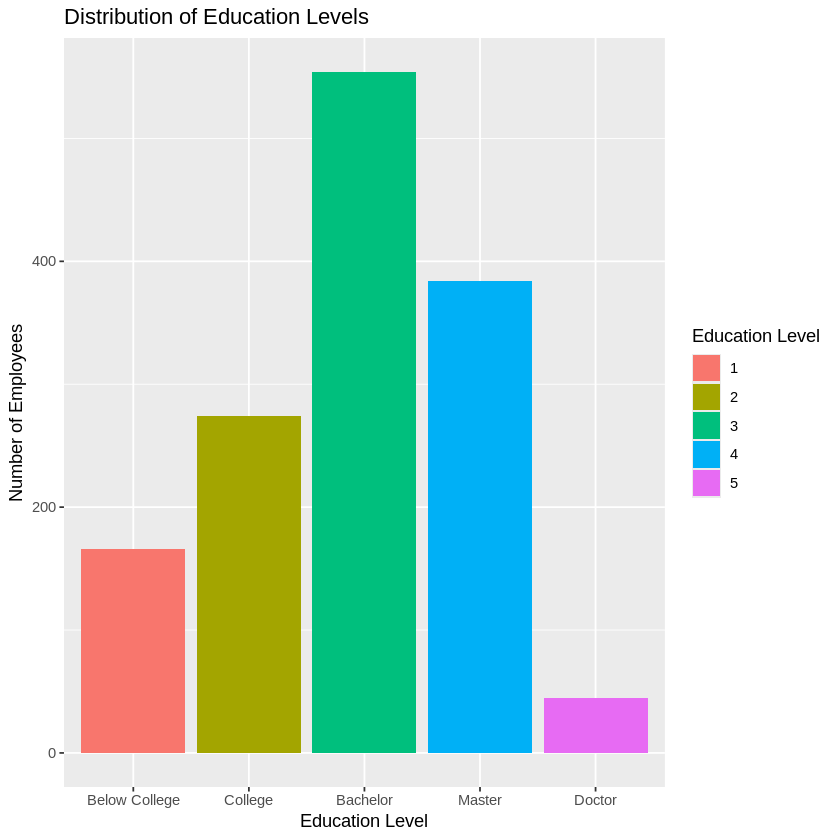

In [ ]:
ggplot(data, aes(x = factor(Education, levels = c(1, 2, 3, 4, 5)),
                 fill = factor(Education))) +
  geom_bar() +
  labs(title = "Distribution of Education Levels",
       x = "Education Level",
       y = "Number of Employees",
       fill = "Education Level") +
  scale_x_discrete(labels = c("1" = "Below College", "2" = "College", "3" = "Bachelor",
                              "4" = "Master", "5" = "Doctor"))

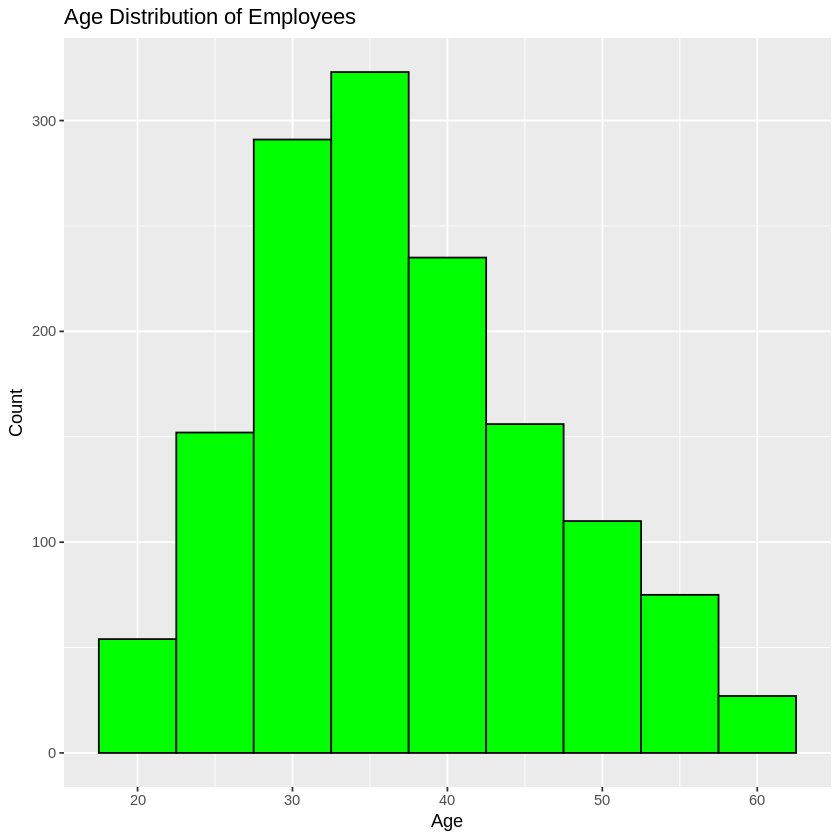

In [ ]:
ggplot(data, aes(x = Age)) +
  geom_histogram(binwidth = 5, fill = "green", color = "black") +
  labs(title = "Age Distribution of Employees",
       x = "Age",
       y = "Count")

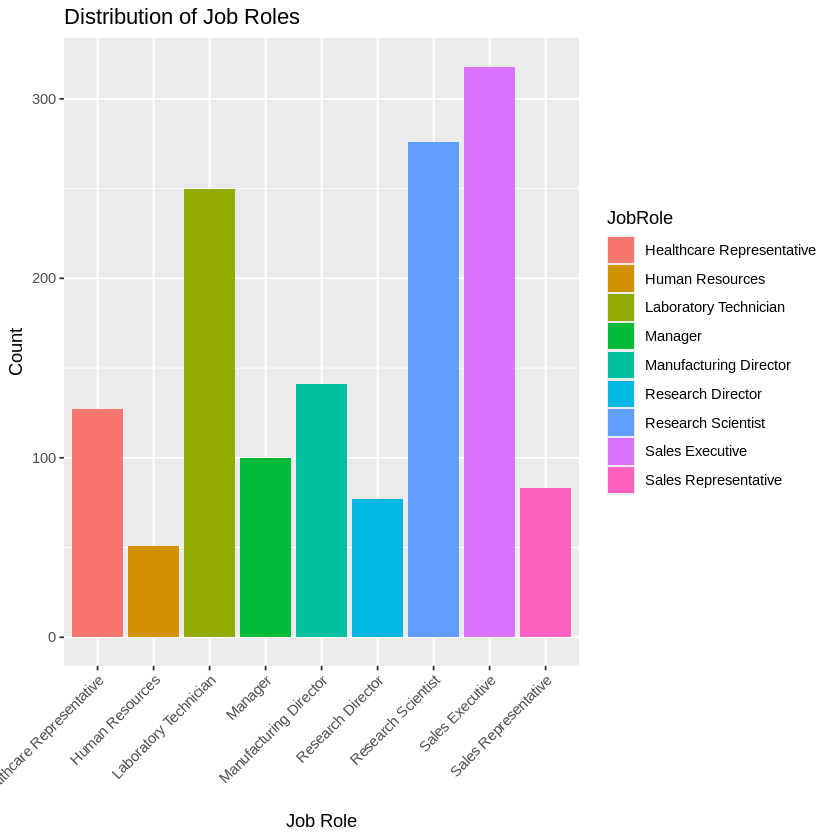

In [ ]:
ggplot(data, aes(x = JobRole, fill = JobRole)) +
  geom_bar() +
  labs(title = "Distribution of Job Roles",
       x = "Job Role",
       y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [ ]:
install.packages("shinydashboard")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("quanteda")
install.packages("sentimentr")

library(quanteda)
library(sentimentr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘ISOcodes’, ‘fastmatch’, ‘SnowballC’, ‘stopwords’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘NLP’, ‘zoo’, ‘dtt’, ‘english’, ‘mgsub’, ‘qdapRegex’, ‘slam’, ‘lexicon’, ‘syuzhet’, ‘textclean’, ‘textshape’


Package version: 4.3.0
Unicode version: 14.0
ICU version: 70.1

Parallel computing: 2 of 2 threads used.

See https://quanteda.io for tutorials and examples.



In [ ]:
# Example text data
texts <- c("GeeksforGeeks is a leading platform that provides computer science resources and coding
                   challenges for programmers and technology enthusiasts, along with interview and exam
                   preparations for upcoming aspirants. With a strong emphasis on enhancing coding skills and
                   knowledge, it has become a trusted destination for over 12 million plus registered users worldwide.
                   The platform offers a vast collection of tutorials, practice problems, interview tutorials, articles,
                    and courses, covering various domains of computer science.")

# Create a corpus
corpus <- corpus(texts)

# Tokenize the corpus and remove punctuation
tokens <- tokens(corpus, remove_punct = TRUE)

# Remove stopwords
tokens <- tokens_remove(tokens, stopwords("en"))

# Create a document-feature matrix (DFM)
dfm <- dfm(tokens)

In [ ]:
print(topfeatures(dfm, n = 10))

     platform      computer       science        coding     interview 
            2             2             2             2             2 
    tutorials geeksforgeeks       leading      provides     resources 
            2             1             1             1             1 


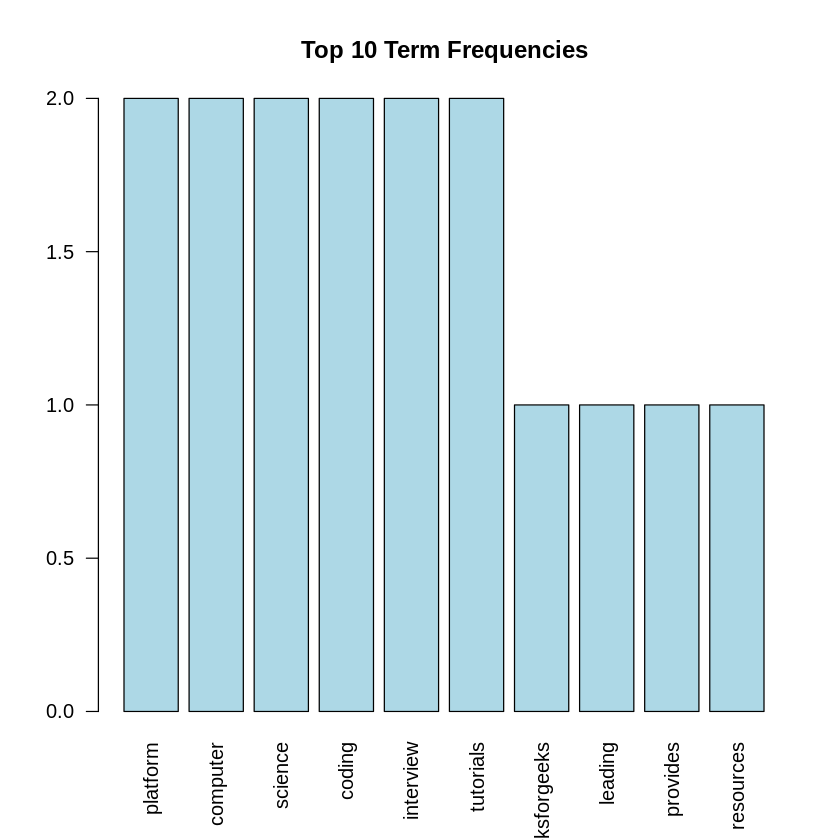

In [ ]:
top_terms <- topfeatures(dfm, n = 10)
barplot(top_terms, col = "lightblue", main = "Top 10 Term Frequencies", las = 2)

In [ ]:
texts_clean <- as.character(corpus)
# Perform sentiment analysis using sentimentr
sentiment_scores <- sentiment(texts_clean)

# Print sentiment scores
print(sentiment_scores)

Key: <element_id, sentence_id>
   element_id sentence_id word_count   sentiment
        <int>       <int>      <int>       <num>
1:          1           1         27  0.30792014
2:          1           2         23  0.33362306
3:          1           3         21 -0.02182179


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: RColorBrewer



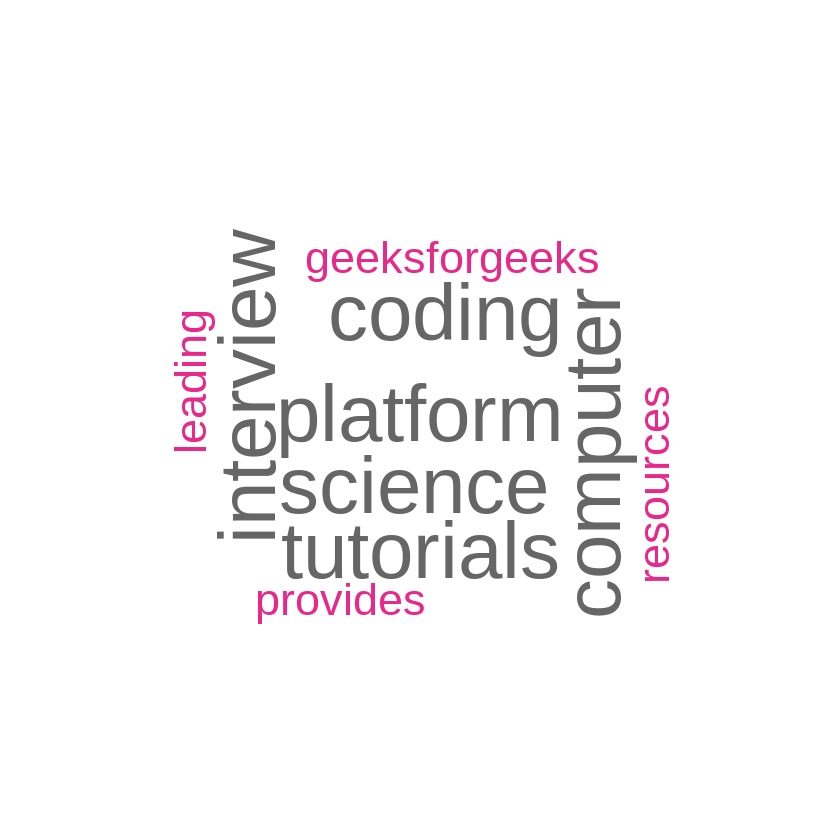

In [ ]:
install.packages("wordcloud")
library(wordcloud)

wordcloud(words = names(top_terms), freq = top_terms, min.freq = 1,
          max.words = 200, random.order = FALSE, rot.per = 0.35,
          colors = brewer.pal(8, "Dark2"))